3.1 Panorama general
En esta sección vas a aprender a visualizar relaciones entre variables con Seaborn, aprovechando diagramas de dispersión, líneas y mapeos semánticos para mostrar más información en un mismo gráfico.

Diagramas de dispersión (scatterplot) para correlaciones y patrones.
Diagramas de líneas (lineplot) para tendencias y series temporales.
Mapeos semánticos (hue, size, style) para incorporar variables adicionales.
Todos los ejemplos están listos para copiar y pegar: incluyen los imports necesarios, configuran un tema agradable y muestran cómo complementar el resultado con funciones de Matplotlib. Cuando se requiere agregar jitter, también se importa desde NumPy.

3.2 Diagramas de dispersión con scatterplot
El scatterplot muestra la relación entre dos variables numéricas, permitiendo ver correlaciones, patrones y valores atípicos. Es la base para analizar relaciones.

A) Dispersión básica

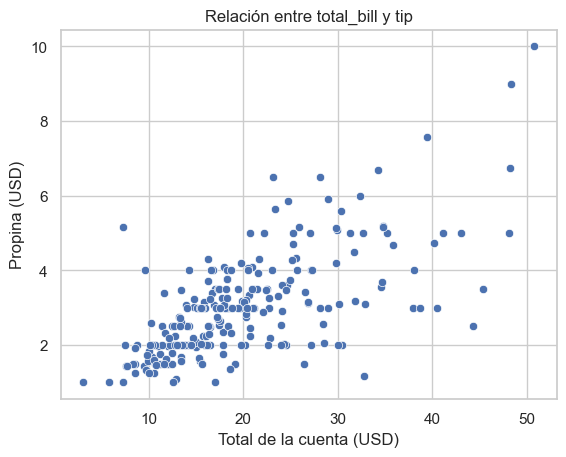

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tema visual recomendado
sns.set_theme(style="whitegrid", context="notebook")

# Dataset de ejemplo
tips = sns.load_dataset("tips")

# Dispersión simple: total_bill vs tip
sns.scatterplot(data=tips, x="total_bill", y="tip")
plt.title("Relación entre total_bill y tip")
plt.xlabel("Total de la cuenta (USD)")
plt.ylabel("Propina (USD)")
plt.show()

B) Reducir solapamiento: transparencia y tamaño fijo

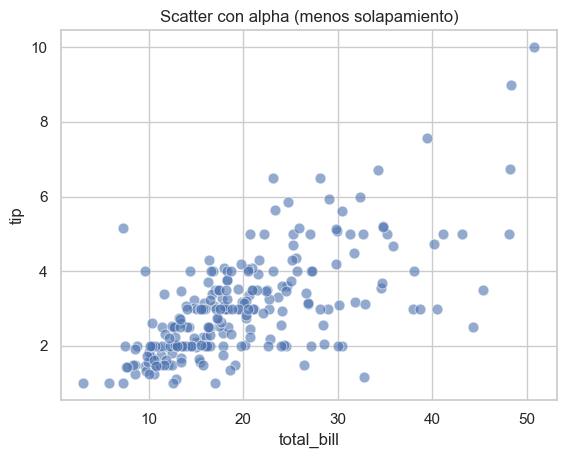

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips")

sns.scatterplot(
    data=tips, x="total_bill", y="tip",
    alpha=0.6,        # transparencia
    s=60              # tamaño fijo del marcador
)
plt.title("Scatter con alpha (menos solapamiento)")
plt.show()

C) Categorización con hue (colores)

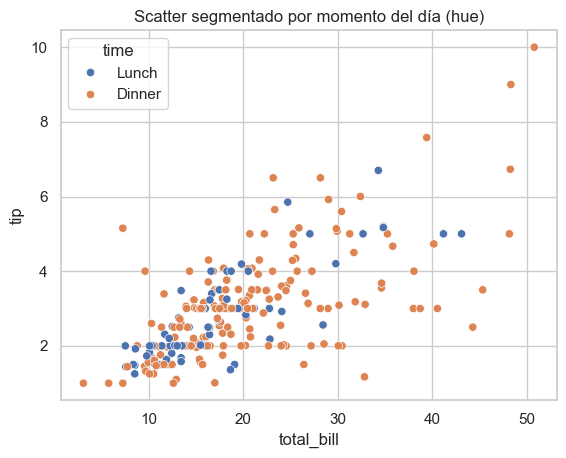

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips")

sns.scatterplot(
    data=tips,
    x="total_bill", y="tip",
    hue="time"         # Lunch vs Dinner
)
plt.title("Scatter segmentado por momento del día (hue)")
plt.show()

D) Jitter para variables discretas
El jitter consiste en sumar un ruido aleatorio pequeño a una variable discreta para separar puntos solapados y revelar su densidad real.

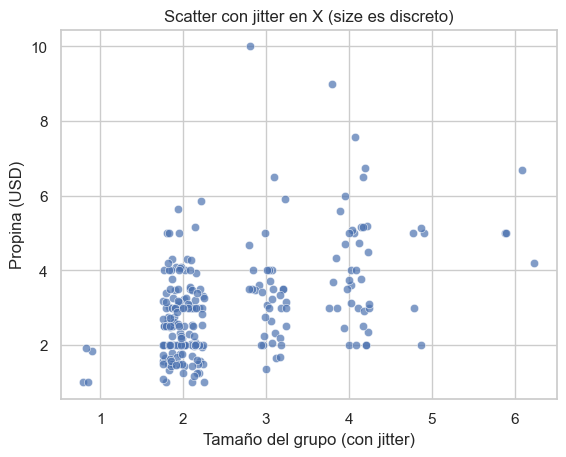

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips").copy()

# Agregar jitter manual al eje X si hay discretización fuerte
jitter = (np.random.rand(len(tips)) - 0.5) * 0.5
sns.scatterplot(
    data=tips,
    x=tips["size"] + jitter,
    y="tip",
    alpha=0.7
)
plt.title("Scatter con jitter en X (size es discreto)")
plt.xlabel("Tamaño del grupo (con jitter)")
plt.ylabel("Propina (USD)")
plt.show()

Tip: combiná scatterplot con sns.regplot para agregar una tendencia lineal rápida o con Seaborn Objects para ajustes avanzados.

3.3 Diagramas de líneas con lineplot
lineplot muestra cómo evoluciona una variable ordenada (tiempo, índice, categoría ordinal). Puede calcular agregaciones cuando hay varias observaciones por punto.

A) Línea básica (tiempo vs valor)
Primeros registros del dataset fmri:


subject	timepoint	event	region	signal
s13	18	stim	parietal	-0.017552
s5	14	stim	parietal	-0.080883
s12	18	stim	parietal	-0.081033
s11	18	stim	parietal	-0.046134
s10	18	stim	parietal	-0.037970

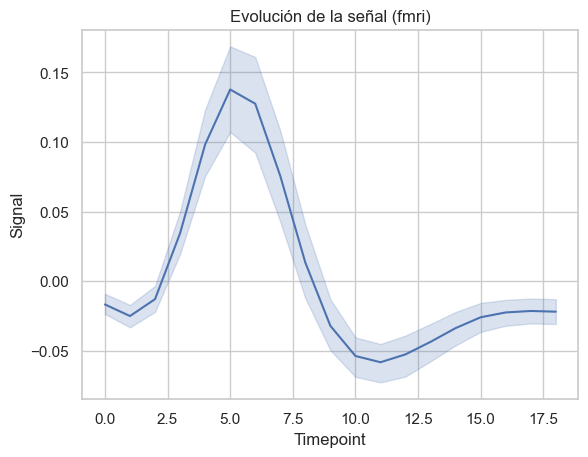

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
fmri = sns.load_dataset("fmri")  # señal a lo largo del tiempo

sns.lineplot(data=fmri, x="timepoint", y="signal")
plt.title("Evolución de la señal (fmri)")
plt.xlabel("Timepoint")
plt.ylabel("Signal")
plt.show()

B) Líneas por categoría con hue y style

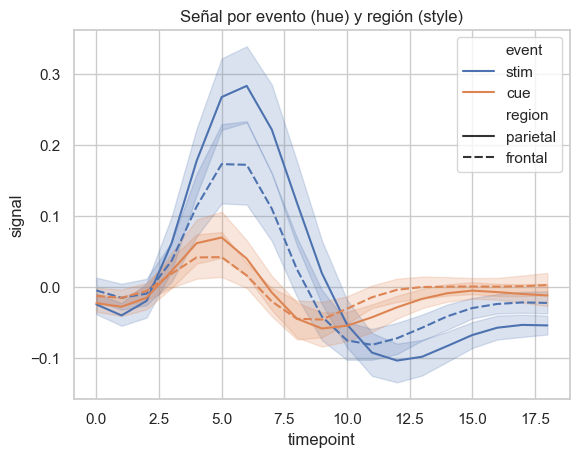

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
fmri = sns.load_dataset("fmri")

sns.lineplot(
    data=fmri,
    x="timepoint", y="signal",
    hue="event",           # 'stim' vs 'cue'
    style="region"         # 'frontal' vs 'parietal'
)
plt.title("Señal por evento (hue) y región (style)")
plt.show()

C) Bandas de confianza configurables

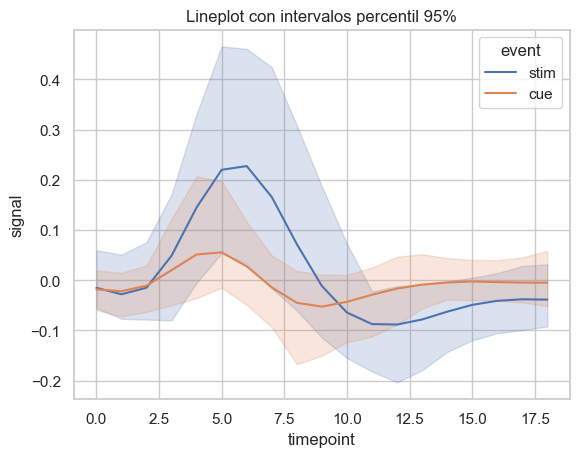

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
fmri = sns.load_dataset("fmri")

# errorbar=("pi", 95) intervalo percentil al 95%
sns.lineplot(
    data=fmri, x="timepoint", y="signal",
    hue="event",
    errorbar=("pi", 95)
)
plt.title("Lineplot con intervalos percentil 95%")
plt.show()

D) Una línea por serie (sin agregación)

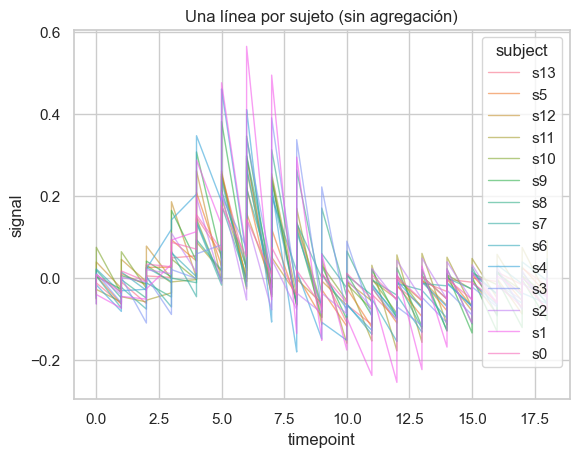

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
fmri = sns.load_dataset("fmri")

sns.lineplot(
    data=fmri,
    x="timepoint", y="signal",
    hue="subject",         # cada sujeto con color propio
    estimator=None,         # evita el promedio
    linewidth=1,
    alpha=0.6
)
plt.title("Una línea por sujeto (sin agregación)")
plt.show()

3.4 Mapeos semánticos (hue, size, style)
Seaborn permite mapear más variables a canales visuales adicionales. Usá hue para colores, size para magnitudes y style para diferenciar categorías adicionales.

A) Scatter con hue, size y style

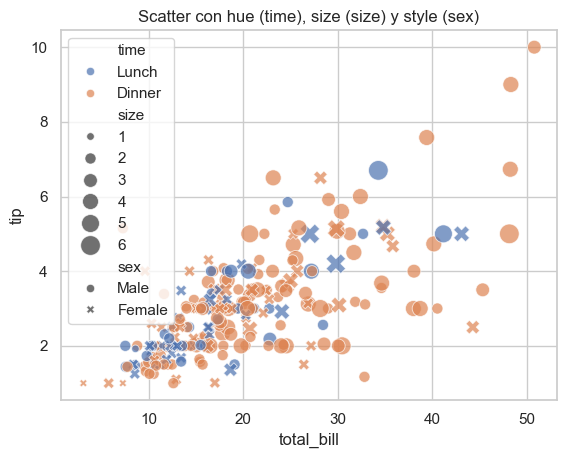

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips")

sns.scatterplot(
    data=tips,
    x="total_bill", y="tip",
    hue="time",         # color por momento del día
    size="size",        # tamaño por tamaño de grupo
    style="sex",        # marcador por sexo
    sizes=(30, 200),
    alpha=0.7
)
plt.title("Scatter con hue (time), size (size) y style (sex)")
plt.show()

B) relplot con facetas

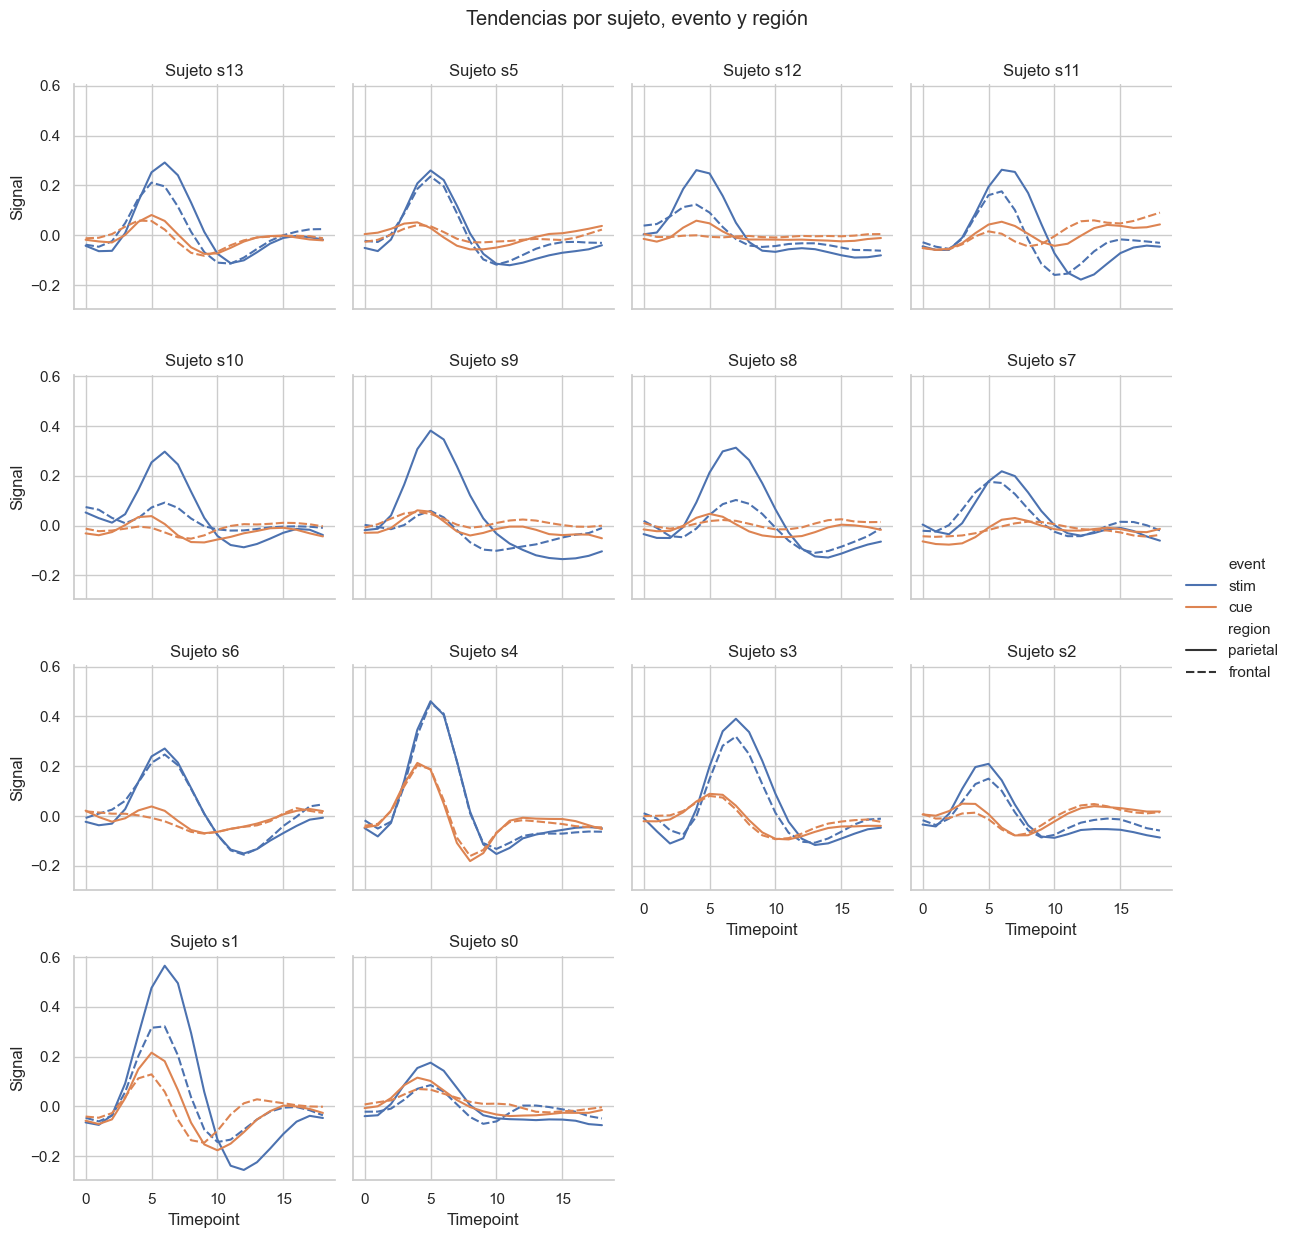

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
fmri = sns.load_dataset("fmri")

g = sns.relplot(
    data=fmri,
    kind="line",
    x="timepoint", y="signal",
    hue="event",
    style="region",
    col="subject",
    col_wrap=4,
    height=3,
    errorbar=None
)
g.set_titles("Sujeto {col_name}")
g.set_axis_labels("Timepoint", "Signal")
plt.suptitle("Tendencias por sujeto, evento y región", y=1.03)
plt.show()

C) Añadir una recta de tendencia

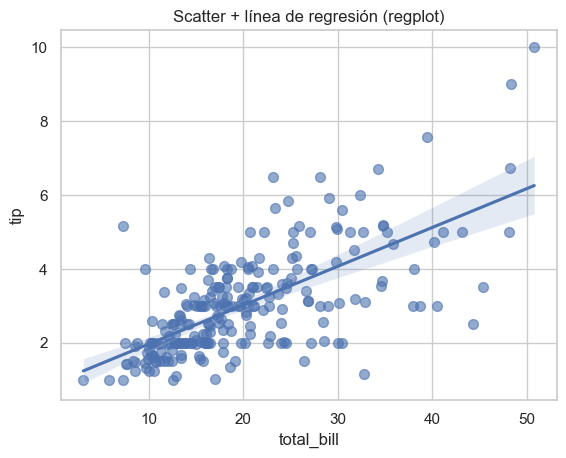

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips")

sns.regplot(
    data=tips,
    x="total_bill", y="tip",
    scatter_kws={"alpha": 0.6, "s": 50}
)
plt.title("Scatter + línea de regresión (regplot)")
plt.show()

D) Recta de tendencia con Seaborn Objects

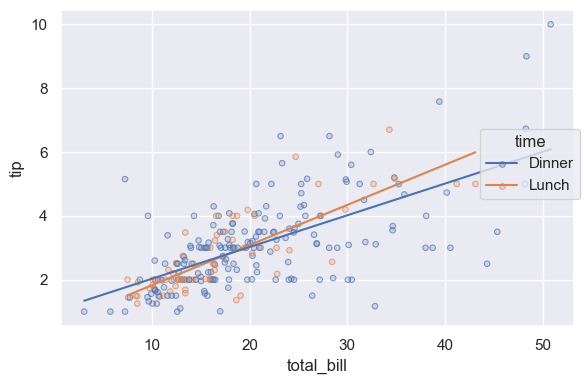

In [10]:
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
tips = sns.load_dataset("tips")

(
    so.Plot(tips, x="total_bill", y="tip", color="time")
      .add(so.Dots(alpha=0.7))
      .add(so.Line(), so.PolyFit(order=1))  # recta de tendencia
      .layout(size=(6, 4))
).show()

3.5 Consejos prácticos y buenas prácticas
Tipo de gráfico: si X es temporal u ordenada, preferí lineplot; si ambas variables son numéricas sin orden, comenzá con scatterplot.
Agregaciones: controlá las bandas con errorbar (("pi", 95) o None) según necesites resumen o todas las series.
Semántica: usá hue para categorías, size para magnitud y style para otra variable discreta. Si hay demasiadas categorías, preferí facetas con col/row.
Legibilidad: ajustá alpha y s en scatterplot cuando hay solapamiento; considerá jitter si el eje es discreto.
Color: elegí paletas compatibles con daltonismo (por ejemplo, palette="colorblind" o sns.set_palette("deep")).

Mini-checklist
¿Relación sin orden? scatterplot + tendencia opcional.
¿Serie temporal o tendencia? lineplot.
¿Necesitás más variables? hue/size/style o facetas.
¿Muchas categorías? Mejor facetas que una paleta con demasiados colores.
¿Se solapan puntos? Ajustá alpha, s y agregá jitter cuando corresponda.